# Healthcare Fraud Detection Notebook

This is a self-contained Jupyter notebook version of the project pipeline:

1. Load and clean the healthcare transactions dataset from SQLite
2. Run exploratory analysis on claim amounts and core claim context
3. Export the processed feature dataset to `data/processed`
4. Use notebook-side pipeline code copied from the scripts
5. Run single-value inference, SHAP, and test inference inside Jupyter

It does not rely on importing the project `src` modules for the notebook demo path.


In [1]:
from pathlib import Path
import os
import sqlite3
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
import shap
from IPython.display import HTML, display
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Input, LSTM, RepeatVector, TimeDistributed
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "database").exists() and (PROJECT_ROOT.parent / "database").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DB_PATH = PROJECT_ROOT / "database" / "healthcare.db"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SAMPLES_DIR = PROJECT_ROOT / "data" / "samples"
MODELS_DIR = PROJECT_ROOT / "models"

for folder in [PROCESSED_DIR, SAMPLES_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Database path:", DB_PATH)


c:\Users\irfui\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: d:\IBM final
Database path: d:\IBM final\database\healthcare.db


## 1. Data Loading

We start from the raw `Healthcare_transactions` table stored in SQLite. This is the same source used by the training pipeline.


In [2]:
with sqlite3.connect(DB_PATH) as conn:
    raw_df = pd.read_sql(
        "SELECT * FROM Healthcare_transactions",
        conn,
        parse_dates=["service_start", "service_end", "admission_date", "patient_dob"],
    )

print(f"Loaded {raw_df.shape[0]:,} records and {raw_df.shape[1]} columns.")
raw_df.head(3)


Loaded 312,773 records and 22 columns.


,transaction_id,patient_id,provider_id,claim_type,service_start,service_end,admission_date,billing_amount,deductible_context,coinsurance_context,...,diagnosis_context,primary_procedure,primary_service,patient_dob,gender_context,demographic_context,has_diabetes,has_chf,has_cancer,has_copd
0,895941123171445,00042C476CC26F05,2300YM,Inpatient,2008-05-13,2008-05-15,2008-05-13,12000.0,1024.0,0.0,...,71536,8151,None,1927-03-01,1,1,2,1,2,2
1,895771123136618,000825B0BCF3887D,2501QH,Inpatient,2008-09-18,2008-09-21,2008-09-18,5000.0,1024.0,0.0,...,72981,None,None,1911-01-01,1,1,1,1,1,1
2,895721123161246,000A24F744271835,3400BT,Inpatient,2008-05-25,2008-05-29,2008-05-25,8000.0,1024.0,0.0,...,486,9919,None,1962-03-01,2,1,1,1,2,1


## 2. Cleaning and Standardization

The CMS-style binary columns use `1 = Yes` and `2 = No`. We convert those into clean `1/0` values and derive a few human-readable timeline features for EDA.


In [3]:
df_clean = raw_df.copy()

binary_cols = ["has_diabetes", "has_chf", "has_cancer", "has_copd"]
for col in binary_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].replace({2: 0, 1: 1}).fillna(0).astype(int)

if "gender_context" in df_clean.columns:
    df_clean["gender_context"] = df_clean["gender_context"].replace({2: 0, 1: 1}).fillna(0).astype(int)

for col in ["service_start", "service_end", "admission_date", "patient_dob"]:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce")

df_clean["service_duration"] = (
    (df_clean["service_end"] - df_clean["service_start"]).dt.days.clip(lower=0)
)
df_clean["age"] = (
    (df_clean["service_start"] - df_clean["patient_dob"]).dt.days // 365.25
).clip(lower=0)

missing_summary = (
    df_clean[["billing_amount", "service_start", "service_end", "age"]]
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

print("Cleaned binary flags and date columns.")
missing_summary


Cleaned binary flags and date columns.


,missing_count
billing_amount,0
service_start,0
service_end,0
age,0


## 3. Exploratory Analysis

Before training the anomaly model, we inspect the billing amount distribution and how claim amounts behave against patient context.


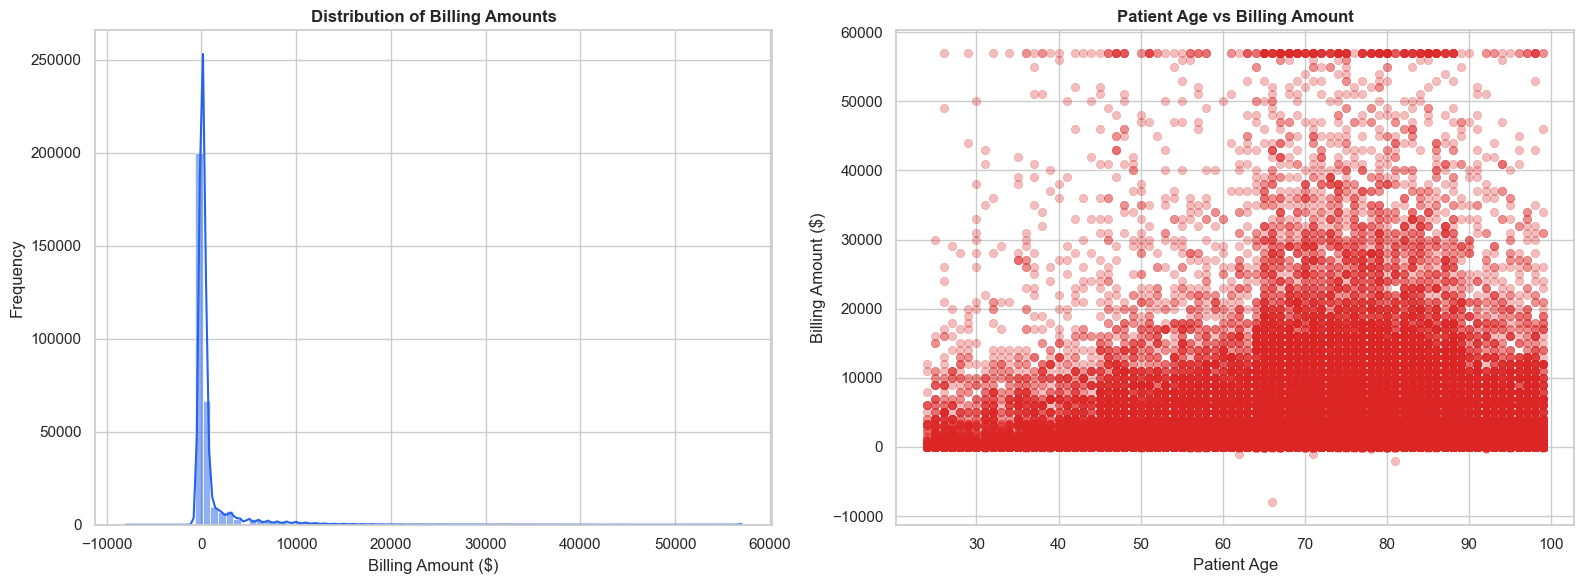

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    df_clean["billing_amount"],
    bins=80,
    kde=True,
    ax=axes[0],
    color="#2563eb",
)
axes[0].set_title("Distribution of Billing Amounts", fontweight="bold")
axes[0].set_xlabel("Billing Amount ($)")
axes[0].set_ylabel("Frequency")

sns.scatterplot(
    data=df_clean,
    x="age",
    y="billing_amount",
    alpha=0.3,
    ax=axes[1],
    color="#dc2626",
    edgecolor=None,
)
axes[1].set_title("Patient Age vs Billing Amount", fontweight="bold")
axes[1].set_xlabel("Patient Age")
axes[1].set_ylabel("Billing Amount ($)")

plt.tight_layout()
plt.show()


## 4. Notebook-Side Pipeline Helpers

The next cell contains notebook-safe versions of the core pipeline code, copied and adapted from the scripts so this notebook can run independently inside Jupyter.


In [5]:
STATIC_FEATURE_COLUMNS = [
    "billing_amount_log",
    "deductible_context",
    "coinsurance_context",
    "provider_avg_billing",
    "provider_std_billing",
    "provider_deviation_score",
    "service_duration",
    "age",
    "rolling_mean_7",
    "rolling_std_7",
    "has_diabetes",
    "has_chf",
    "has_cancer",
    "has_copd",
    "patient_hoarding_index",
    "dx_px_combo_spike",
]

SEQUENCE_FEATURE_COLUMNS = [
    "billing_amount_log",
    "time_gap",
    "services_per_day",
    "rolling_mean_7",
    "rolling_activity_7",
]

DEFAULT_COLUMN_VALUES = {
    "billing_amount": 0.0,
    "deductible_context": 0.0,
    "coinsurance_context": 0.0,
    "claim_type": "UNKNOWN",
    "diagnosis_context": "UNKNOWN",
    "primary_procedure": "NONE",
    "provider_id": "UNKNOWN",
    "patient_id": "UNKNOWN",
    "transaction_id": 0,
    "has_diabetes": 0,
    "has_chf": 0,
    "has_cancer": 0,
    "has_copd": 0,
}

IFOREST_CONTAMINATION = 0.08
LSTM_NORMAL_FILTER_PERCENTILE = 10
HYBRID_THRESHOLD_PERCENTILE = 92
NORMAL_ZONE_MAX = 1.30
HIGH_RISK_ZONE_MIN = 1.85

def get_connection():
    return sqlite3.connect(DB_PATH)

def load_full_dataset():
    with get_connection() as conn:
        df = pd.read_sql(
            "SELECT * FROM Healthcare_transactions",
            conn,
            parse_dates=["service_start", "service_end", "admission_date", "patient_dob"],
        )
    return df

def load_provider_history(provider_id):
    with get_connection() as conn:
        queries = [
            """
            SELECT * FROM healthcare_features
            WHERE provider_id = ?
            ORDER BY service_start
            """,
            """
            SELECT * FROM Healthcare_transactions
            WHERE provider_id = ?
            ORDER BY service_start
            """,
        ]
        df = pd.DataFrame()
        for query in queries:
            try:
                df = pd.read_sql(
                    query,
                    conn,
                    params=(provider_id,),
                    parse_dates=["service_start", "service_end", "admission_date", "patient_dob"],
                )
                if not df.empty:
                    break
            except Exception:
                continue
    return df

def _ensure_required_columns(df):
    df = df.copy()
    for col, default in DEFAULT_COLUMN_VALUES.items():
        if col not in df.columns:
            df[col] = default
    if "service_start" not in df.columns:
        df["service_start"] = pd.NaT
    if "service_end" not in df.columns:
        df["service_end"] = df["service_start"]
    if "age" not in df.columns:
        df["age"] = np.nan
    if "billing_amount_log" in df.columns:
        missing_billing = df["billing_amount"].isna() | (df["billing_amount"] == 0)
        recovered_billing = np.expm1(pd.to_numeric(df["billing_amount_log"], errors="coerce"))
        df.loc[missing_billing, "billing_amount"] = recovered_billing.loc[missing_billing]
    numeric_cols = [
        "billing_amount", "deductible_context", "coinsurance_context", "transaction_id",
        "has_diabetes", "has_chf", "has_cancer", "has_copd", "age",
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["provider_id"] = df["provider_id"].astype(str).str.strip()
    df["patient_id"] = df["patient_id"].astype(str).str.strip()
    df["claim_type"] = df["claim_type"].astype(str).str.strip().replace({"Outpatient (Same Day)": "Outpatient", "Inpatient (Admitted)": "Inpatient"})
    df["diagnosis_context"] = df["diagnosis_context"].astype(str).str.strip().replace({"": "UNKNOWN"})
    df["primary_procedure"] = df["primary_procedure"].astype(str).str.strip().replace({"": "NONE"})
    return df

def build_features(df):
    df = _ensure_required_columns(df)
    df["service_start"] = pd.to_datetime(df["service_start"], errors="coerce")
    df["service_end"] = pd.to_datetime(df["service_end"], errors="coerce")
    df["service_end"] = df["service_end"].fillna(df["service_start"])
    df["service_duration"] = (df["service_end"] - df["service_start"]).dt.days.clip(lower=0)
    df["day_of_week"] = df["service_start"].dt.dayofweek
    df["month"] = df["service_start"].dt.month
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    if "patient_dob" in df.columns:
        df["patient_dob"] = pd.to_datetime(df["patient_dob"], errors="coerce")
        hist_age = ((df["service_start"] - df["patient_dob"]).dt.days // 365.25).clip(lower=0)
        df["age"] = hist_age if "age" not in df.columns else df["age"].fillna(hist_age)
    if "patient_age" in df.columns:
        df["age"] = df["patient_age"] if "age" not in df.columns else df["age"].fillna(df["patient_age"])
    conditions = [df["age"].isna(), df["age"] <= 18, df["age"] <= 40, df["age"] <= 60]
    choices = ["unknown", "child", "young", "middle"]
    df["age_band"] = np.select(conditions, choices, default="senior")
    df = df.sort_values(["provider_id", "service_start"]).reset_index(drop=True)
    p99 = np.percentile(df["billing_amount"].fillna(0), 99)
    df["billing_amount"] = np.clip(df["billing_amount"], 0, p99)
    df["billing_amount_log"] = np.log1p(df["billing_amount"])
    global_avg_log = df["billing_amount_log"].mean()
    global_std_log = df["billing_amount_log"].std()
    shifted_billing_log = df.groupby("provider_id")["billing_amount_log"].shift(1)
    df["provider_avg_billing"] = shifted_billing_log.groupby(df["provider_id"]).expanding().mean().reset_index(level=0, drop=True).fillna(global_avg_log)
    df["provider_std_billing"] = shifted_billing_log.groupby(df["provider_id"]).expanding().std().reset_index(level=0, drop=True).fillna(global_std_log)
    df["provider_deviation_score"] = (df["billing_amount_log"] - df["provider_avg_billing"]) / (df["provider_std_billing"] + 1e-6)
    df["provider_deviation_score"] = np.clip(df["provider_deviation_score"], -10, 10)
    df["provider_age_avg"] = df.groupby(["provider_id", "age_band"])["billing_amount_log"].transform(lambda x: x.shift(1).expanding().mean()).fillna(df["provider_avg_billing"])
    df["claim_type_avg"] = df.groupby(["provider_id", "claim_type"])["billing_amount_log"].transform(lambda x: x.shift(1).expanding().mean()).fillna(df["provider_avg_billing"])
    df["diagnosis_avg"] = df.groupby(["provider_id", "diagnosis_context"])["billing_amount_log"].transform(lambda x: x.shift(1).expanding().mean()).fillna(df["claim_type_avg"])
    df["primary_procedure"] = df["primary_procedure"].fillna("NONE")
    df["procedure_avg"] = df.groupby(["provider_id", "primary_procedure"])["billing_amount_log"].transform(lambda x: x.shift(1).expanding().mean()).fillna(df["claim_type_avg"])
    df["dx_px_combo"] = df["diagnosis_context"].astype(str) + "_" + df["primary_procedure"].astype(str)
    df["dx_px_combo_avg"] = df.groupby(["provider_id", "dx_px_combo"])["billing_amount_log"].transform(lambda x: x.shift(1).expanding().mean()).fillna(df["diagnosis_avg"])
    df["amount_vs_provider"] = df["billing_amount_log"] - df["provider_avg_billing"]
    df["amount_vs_provider_age"] = df["billing_amount_log"] - df["provider_age_avg"]
    df["amount_vs_claim_type"] = df["billing_amount_log"] - df["claim_type_avg"]
    df["amount_vs_diagnosis"] = df["billing_amount_log"] - df["diagnosis_avg"]
    df["amount_vs_procedure"] = df["billing_amount_log"] - df["procedure_avg"]
    df["dx_px_combo_spike"] = df["billing_amount_log"] - df["dx_px_combo_avg"]
    df["relative_provider_deviation"] = np.where(df["provider_avg_billing"] != 0, df["amount_vs_provider"] / df["provider_avg_billing"], 0)
    df["is_new_patient"] = (~df.duplicated(subset=["provider_id", "patient_id"])).astype(int)
    df["unique_patients_to_date"] = df.groupby("provider_id")["is_new_patient"].cumsum()
    df["total_visits_to_date"] = df.groupby("provider_id").cumcount() + 1
    df["patient_hoarding_index"] = np.where(df["total_visits_to_date"] > 5, df["unique_patients_to_date"] / df["total_visits_to_date"], 1.0)
    df["weekend_avg_billing"] = df.groupby(["provider_id", "is_weekend"])["billing_amount_log"].transform(lambda x: x.shift(1).expanding().mean()).fillna(global_avg_log)
    df["weekend_fraud_spike"] = np.where(df["is_weekend"] == 1, df["billing_amount_log"] - df["weekend_avg_billing"], 0)
    df["time_gap"] = df.groupby("provider_id")["service_start"].diff().dt.total_seconds() / 3600.0
    df["time_gap"] = df["time_gap"].fillna(0).clip(lower=0, upper=720)
    df["service_date"] = df["service_start"].dt.date
    df["services_per_day"] = df.groupby(["provider_id", "service_date"])["transaction_id"].transform("count")
    df["rolling_mean_7"] = shifted_billing_log.groupby(df["provider_id"]).rolling(7, min_periods=1).mean().reset_index(level=0, drop=True).fillna(df["provider_avg_billing"])
    df["rolling_std_7"] = shifted_billing_log.groupby(df["provider_id"]).rolling(7, min_periods=1).std().reset_index(level=0, drop=True).fillna(0)
    shifted_activity = df.groupby("provider_id")["services_per_day"].shift(1)
    df["rolling_activity_7"] = shifted_activity.groupby(df["provider_id"]).rolling(7, min_periods=1).mean().reset_index(level=0, drop=True).fillna(1)
    cols_to_drop = ["is_new_patient", "unique_patients_to_date", "total_visits_to_date", "weekend_avg_billing", "dx_px_combo", "dx_px_combo_avg", "claim_type_avg", "diagnosis_avg", "procedure_avg", "service_date"]
    df = df.drop(columns=cols_to_drop, errors="ignore")
    df = df.replace([np.inf, -np.inf], 0.0).infer_objects(copy=False)
    df = df.fillna(0)
    return df

def compute_hybrid_score(iforest_norm, lstm_norm, has_temporal_signal):
    if_values = np.asarray(iforest_norm, dtype=float)
    lstm_values = np.asarray(lstm_norm, dtype=float)
    temporal_mask = np.asarray(has_temporal_signal, dtype=bool)
    peak_signal = np.maximum(if_values, lstm_values)
    agreement_bonus = 0.10 * np.minimum(np.maximum(if_values, 0.0), np.maximum(lstm_values, 0.0))
    temporal_score = (0.60 * if_values) + (0.20 * lstm_values) + (0.20 * peak_signal) + agreement_bonus
    return np.where(temporal_mask, temporal_score, if_values)


## 5. SHAP and Inference Helpers

This section keeps the explanation and single-transaction inference logic inside the notebook itself.


In [6]:
def train_models_from_dataframe(df_train):
    df_train = build_features(df_train.copy())
    if "service_start" in df_train.columns:
        df_train = df_train.sort_values(["provider_id", "service_start"]).reset_index(drop=True)
    else:
        df_train = df_train.sort_values(["provider_id"]).reset_index(drop=True)
    X_static = df_train[STATIC_FEATURE_COLUMNS].values
    scaler_static_local = RobustScaler()
    X_static_scaled = scaler_static_local.fit_transform(X_static)
    iso_forest = IsolationForest(contamination=IFOREST_CONTAMINATION, n_estimators=200, random_state=42)
    iso_forest.fit(X_static_scaled)
    scaler_seq_local = RobustScaler()
    df_train[SEQUENCE_FEATURE_COLUMNS] = scaler_seq_local.fit_transform(df_train[SEQUENCE_FEATURE_COLUMNS])
    if_scores = iso_forest.decision_function(X_static_scaled)
    normal_mask = if_scores > np.percentile(if_scores, LSTM_NORMAL_FILTER_PERCENTILE)
    df_normal = df_train[normal_mask].copy()
    sequences = []
    window = 7
    for _, group in df_normal.groupby("provider_id"):
        data = group[SEQUENCE_FEATURE_COLUMNS].values
        if len(data) < window:
            continue
        for i in range(window, len(data) + 1):
            sequences.append(data[i - window:i])
    X_seq = np.array(sequences)
    if len(X_seq) == 0:
        X_seq = np.zeros((10, window, len(SEQUENCE_FEATURE_COLUMNS)))
    timesteps = X_seq.shape[1]
    features = X_seq.shape[2]
    inputs = Input(shape=(timesteps, features))
    encoded = LSTM(48, return_sequences=False)(inputs)
    repeated = RepeatVector(timesteps)(encoded)
    decoded = LSTM(48, return_sequences=True)(repeated)
    outputs = TimeDistributed(Dense(features))(decoded)
    autoencoder = Model(inputs, outputs)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
    early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    autoencoder.fit(X_seq, X_seq, epochs=15, batch_size=32, validation_split=0.1, shuffle=True, callbacks=[early_stop], verbose=1)
    joblib.dump(iso_forest, MODELS_DIR / "iforest_model.pkl")
    joblib.dump(scaler_static_local, MODELS_DIR / "scaler_static.pkl")
    joblib.dump(scaler_seq_local, MODELS_DIR / "scaler_seq.pkl")
    autoencoder.save(MODELS_DIR / "lstm_autoencoder.keras")
    return autoencoder

def _extract_shap_row(shap_values):
    shap_array = np.asarray(shap_values[0] if isinstance(shap_values, list) else shap_values)
    if shap_array.ndim == 1:
        return shap_array
    return shap_array[0]

def _extract_expected_value(explainer):
    expected_value = getattr(explainer, "expected_value", 0.0)
    expected_array = np.asarray(expected_value)
    if expected_array.size == 0:
        return 0.0
    return float(expected_array.reshape(-1)[0])

def _format_feature_value(value):
    if pd.isna(value):
        return "N/A"
    if isinstance(value, (np.integer, int)):
        return str(int(value))
    if isinstance(value, (np.floating, float)):
        return f"{float(value):.2f}"
    return str(value)

DRIVER_BULLET_MAP = {
    "Total Claim Amount": "Claim amount is materially above the provider baseline.",
    "Deductible": "Deductible pattern is unusual for this type of claim.",
    "Coinsurance": "Coinsurance pattern differs from comparable claims.",
    "Provider Baseline": "Submitted amount is drifting away from the provider's usual level.",
    "Provider Variance": "Provider billing variability is elevated for this claim.",
    "Provider Deviation": "Recent provider behavior differs from historical norms.",
    "Clinical Mismatch": "Diagnosis and procedure context do not align with typical billing behavior.",
    "7-Day Rolling Mean": "Recent provider billing volume is above its short-term trend.",
    "7-Day Rolling Volatility": "Recent provider billing activity is unusually volatile.",
    "Length of Stay": "Visit duration is inconsistent with expected behavior.",
    "Patient Age": "Patient context differs from comparable claims.",
    "Diabetes Context": "Clinical history contributes to an uncommon claim profile.",
    "CHF Context": "Clinical history contributes to an uncommon claim profile.",
    "Oncology Context": "Clinical history contributes to an uncommon claim profile.",
    "COPD Context": "Clinical history contributes to an uncommon claim profile.",
    "Patient Hoarding (Collusion Risk)": "Patient-provider interaction pattern looks unusually concentrated.",
}

def explain_transaction(transaction, static_cols, model, scaler):
    df_eval = pd.DataFrame([transaction])[static_cols]
    X_scaled = scaler.transform(df_eval.values)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_scaled)
    shap_row = _extract_shap_row(shap_values)
    contributions = pd.DataFrame({"Feature": static_cols, "Value": df_eval.iloc[0].values, "Contribution": shap_row})
    contributions["Abs_Contribution"] = contributions["Contribution"].abs()
    contributions = contributions.sort_values(by="Abs_Contribution", ascending=False)
    return contributions[["Feature", "Value", "Contribution"]]

def explain_in_words(explanation_df):
    if explanation_df.empty:
        return "Explanation unavailable."
    feature_statement_map = {
        "billing_amount_log": "claim amount is materially above the provider baseline",
        "deductible_context": "deductible pattern is unusual for this claim profile",
        "coinsurance_context": "coinsurance pattern differs from comparable claims",
        "provider_avg_billing": "submitted amount differs from the provider's typical billing level",
        "provider_std_billing": "provider billing variability is elevated",
        "provider_deviation_score": "provider behavior differs from historical norms",
        "dx_px_combo_spike": "diagnosis and procedure context appear mismatched",
        "rolling_mean_7": "recent provider billing activity is above trend",
        "rolling_std_7": "recent provider billing activity is unusually volatile",
        "service_duration": "visit duration is inconsistent with expected behavior",
        "age": "patient context differs from comparable claims",
        "has_diabetes": "clinical history contributes to an uncommon claim profile",
        "has_chf": "clinical history contributes to an uncommon claim profile",
        "has_cancer": "clinical history contributes to an uncommon claim profile",
        "has_copd": "clinical history contributes to an uncommon claim profile",
        "patient_hoarding_index": "patient-provider interaction is unusually concentrated",
    }
    reasons = []
    seen = set()
    for _, row in explanation_df.iterrows():
        if len(reasons) >= 2:
            break
        feature = row["Feature"]
        val = row["Value"] if "Value" in row else 1
        if "has_" in feature and val == 0:
            continue
        statement = feature_statement_map.get(feature)
        if not statement or statement in seen:
            continue
        reasons.append(statement)
        seen.add(statement)
    if not reasons:
        return "Primary drivers indicate a strong deviation from the provider baseline."
    return "Primary drivers indicate that " + " and ".join(reasons) + "."

def get_shap_data_for_plotly(transaction, static_cols, model, scaler):
    df_eval = pd.DataFrame([transaction])[static_cols]
    X_scaled = scaler.transform(df_eval.values)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_scaled)
    shap_row = _extract_shap_row(shap_values)
    base_value = _extract_expected_value(explainer)
    feature_map = {
        "billing_amount_log": "Total Claim Amount",
        "deductible_context": "Deductible",
        "coinsurance_context": "Coinsurance",
        "provider_avg_billing": "Provider Baseline",
        "provider_std_billing": "Provider Variance",
        "provider_deviation_score": "Provider Deviation",
        "dx_px_combo_spike": "Clinical Mismatch",
        "rolling_mean_7": "7-Day Rolling Mean",
        "rolling_std_7": "7-Day Rolling Volatility",
        "service_duration": "Length of Stay",
        "age": "Patient Age",
        "has_diabetes": "Diabetes Context",
        "has_chf": "CHF Context",
        "has_cancer": "Oncology Context",
        "has_copd": "COPD Context",
        "patient_hoarding_index": "Patient Hoarding (Collusion Risk)",
    }
    df_chart = pd.DataFrame({"Feature": static_cols, "Value": df_eval.iloc[0].values, "Contribution": shap_row})
    clean_features = []
    clean_contributions = []
    clean_values = []
    for _, row in df_chart.iterrows():
        feat = row["Feature"]
        val = row["Value"]
        cont = row["Contribution"]
        if "has_" in feat and val == 0:
            continue
        clean_features.append(feature_map.get(feat, feat))
        clean_contributions.append(float(cont))
        clean_values.append(_format_feature_value(val))
    final_df = pd.DataFrame({"Feature": clean_features, "Feature_Value": clean_values, "Contribution": clean_contributions})
    final_df["Abs"] = final_df["Contribution"].abs()
    final_df = final_df.sort_values(by="Abs", ascending=False).head(5)
    final_df = final_df.sort_values(by="Contribution")
    return {
        "base_value": float(base_value),
        "component_score": float(base_value + final_df["Contribution"].sum()),
        "features": final_df["Feature"].tolist(),
        "feature_values": final_df["Feature_Value"].tolist(),
        "contributions": final_df["Contribution"].tolist(),
    }

def get_driver_bullets_from_shap_data(shap_data, limit=3):
    if not shap_data:
        return []
    features = shap_data.get("features", [])
    contributions = shap_data.get("contributions", [])
    if not features or not contributions or len(features) != len(contributions):
        return []
    ranked = sorted(zip(features, contributions), key=lambda item: item[1], reverse=True)
    positive = [item for item in ranked if item[1] > 0]
    selected = positive[:limit] if positive else sorted(zip(features, contributions), key=lambda item: abs(item[1]), reverse=True)[:limit]
    return [DRIVER_BULLET_MAP.get(feature, f"{feature} is pushing the claim toward anomaly.") for feature, _ in selected]

iforest_model = None
scaler_static_model = None
lstm_model = None
scaler_seq_model = None
score_stats_model = None
GLOBAL_THRESHOLD = None

def load_saved_inference_artifacts(force=False):
    global iforest_model, scaler_static_model, lstm_model, scaler_seq_model, score_stats_model, GLOBAL_THRESHOLD
    if iforest_model is not None and not force:
        return
    required_paths = {
        "iforest_model": MODELS_DIR / "iforest_model.pkl",
        "scaler_static": MODELS_DIR / "scaler_static.pkl",
        "lstm_autoencoder": MODELS_DIR / "lstm_autoencoder.keras",
        "scaler_seq": MODELS_DIR / "scaler_seq.pkl",
        "score_stats": MODELS_DIR / "score_stats.pkl",
        "threshold": MODELS_DIR / "threshold.pkl",
    }
    missing = [name for name, path in required_paths.items() if not path.exists()]
    if missing:
        raise FileNotFoundError("Missing saved model artifacts: " + ", ".join(missing))
    print("Loading frozen models and baseline statistics for inference...")
    iforest_model = joblib.load(MODELS_DIR / "iforest_model.pkl")
    scaler_static_model = joblib.load(MODELS_DIR / "scaler_static.pkl")
    lstm_model = load_model(MODELS_DIR / "lstm_autoencoder.keras")
    scaler_seq_model = joblib.load(MODELS_DIR / "scaler_seq.pkl")
    score_stats_model = joblib.load(MODELS_DIR / "score_stats.pkl")
    GLOBAL_THRESHOLD = joblib.load(MODELS_DIR / "threshold.pkl")

def _normalize_transaction_payload(new_transaction):
    normalized = DEFAULT_COLUMN_VALUES.copy()
    normalized.update(new_transaction)
    if normalized.get("patient_age") is not None and normalized.get("age") in (None, "", 0):
        normalized["age"] = normalized["patient_age"]
    claim_type = str(normalized.get("claim_type") or "UNKNOWN").strip()
    if "inpatient" in claim_type.lower():
        normalized["claim_type"] = "Inpatient"
    elif "outpatient" in claim_type.lower():
        normalized["claim_type"] = "Outpatient"
    else:
        normalized["claim_type"] = claim_type or "UNKNOWN"
    normalized["service_end"] = normalized.get("service_end") or normalized.get("service_start")
    normalized["admission_date"] = normalized.get("admission_date") or normalized.get("service_start")
    normalized["primary_procedure"] = normalized.get("primary_procedure") or "NONE"
    normalized["diagnosis_context"] = normalized.get("diagnosis_context") or "UNKNOWN"
    normalized["provider_id"] = str(normalized.get("provider_id", "UNKNOWN")).strip().upper()
    normalized["patient_id"] = str(normalized.get("patient_id", "UNKNOWN")).strip().upper()
    return normalized

def classify_alert_zone(anomaly_score):
    if anomaly_score >= HIGH_RISK_ZONE_MIN:
        return "High Risk"
    if anomaly_score > NORMAL_ZONE_MAX:
        return "Suspicious"
    return "Normal"

def run_inference(new_transaction):
    load_saved_inference_artifacts()
    new_transaction = _normalize_transaction_payload(new_transaction)
    provider_id = str(new_transaction["provider_id"])
    start_dt = pd.to_datetime(new_transaction["service_start"], errors="coerce")
    end_dt = pd.to_datetime(new_transaction["service_end"], errors="coerce")
    duration_days = (end_dt - start_dt).days if pd.notna(start_dt) and pd.notna(end_dt) else 0
    new_transaction["service_duration"] = max(0, duration_days)
    history = load_provider_history(provider_id)
    if not history.empty:
        history_records = history.where(pd.notna(history), None).to_dict(orient="records")
        history_records.append(new_transaction.copy())
        history = pd.DataFrame.from_records(history_records)
    else:
        history = pd.DataFrame([new_transaction])
    history["service_start"] = pd.to_datetime(history["service_start"], errors="coerce")
    history = history.sort_values("service_start").reset_index(drop=True)
    history = build_features(history)
    latest = history.iloc[-1].copy()
    X_static = scaler_static_model.transform(latest[STATIC_FEATURE_COLUMNS].values.reshape(1, -1))
    raw_if_score = -iforest_model.decision_function(X_static)[0]
    iforest_norm = (raw_if_score - score_stats_model["if_mean"]) / score_stats_model["if_std"]
    lstm_norm = 0.0
    has_temporal_context = len(history) >= 7
    if has_temporal_context:
        recent_seq_df = history[SEQUENCE_FEATURE_COLUMNS].tail(7)
        seq_scaled = scaler_seq_model.transform(recent_seq_df)
        X_seq = np.array([seq_scaled])
        recon = lstm_model.predict(X_seq, verbose=0)
        raw_lstm_score = np.mean(np.square(X_seq - recon), axis=(1, 2))[0]
        lstm_norm = (raw_lstm_score - score_stats_model["lstm_mean"]) / score_stats_model["lstm_std"]
    raw_hybrid = float(compute_hybrid_score([iforest_norm], [lstm_norm], [has_temporal_context])[0])
    is_anomaly = int(raw_hybrid > GLOBAL_THRESHOLD)
    alert_zone = classify_alert_zone(raw_hybrid)
    latest["hybrid_score"] = raw_hybrid
    result = {
        "transaction_id": int(latest.get("transaction_id", 0)),
        "provider_id": str(provider_id),
        "anomaly_score": float(round(raw_hybrid, 4)),
        "alert_zone": alert_zone,
        "is_normal": "No" if is_anomaly == 1 else "Yes",
    }
    if is_anomaly == 1:
        explanation_df = explain_transaction(latest, STATIC_FEATURE_COLUMNS, iforest_model, scaler_static_model)
        explanation_text = explain_in_words(explanation_df)
        prefix = "High-risk anomaly detected." if alert_zone == "High Risk" else "Suspicious anomaly detected."
        result["reason"] = f"{prefix} {str(explanation_text)}"
    elif alert_zone == "Suspicious":
        result["reason"] = "Pattern is near the anomaly boundary. Manual review is recommended."
    else:
        result["reason"] = "Claim pattern is within the expected range."
    if not has_temporal_context:
        result["reason"] += " (Note: Limited provider history; LSTM analysis inactive)."
    result["shap_data"] = get_shap_data_for_plotly(latest, STATIC_FEATURE_COLUMNS, iforest_model, scaler_static_model)
    result["top_drivers"] = get_driver_bullets_from_shap_data(result["shap_data"])
    return result

def evaluate_transaction_api(transaction_payload):
    return run_inference(transaction_payload)


## 6. Processed Export and Saved Artifacts

This section exports the processed dataset to `data/processed`, refreshes the SQLite `healthcare_features` table, and summarizes the already-trained model artifacts.


In [7]:
df_features = build_features(df_clean.copy())
if "Id" not in df_features.columns:
    df_features.insert(0, "Id", range(1, len(df_features) + 1))

processed_csv_path = PROCESSED_DIR / "healthcare_features.csv"
df_features.to_csv(processed_csv_path, index=False)

sqlite_export = df_features.copy()
datetime_cols = set(sqlite_export.select_dtypes(include=["datetime64[ns]", "datetimetz"]).columns)
for col in sqlite_export.columns:
    sample_value = next((value for value in sqlite_export[col] if pd.notna(value)), None)
    if isinstance(sample_value, pd.Timestamp):
        datetime_cols.add(col)
for col in datetime_cols:
    sqlite_export[col] = pd.to_datetime(sqlite_export[col], errors="coerce")
    sqlite_export[col] = sqlite_export[col].dt.strftime("%Y-%m-%d %H:%M:%S")

with sqlite3.connect(DB_PATH) as conn:
    sqlite_export.to_sql("healthcare_features", conn, if_exists="replace", index=False)

print("Processed features saved to:", processed_csv_path)
print("SQLite table refreshed: healthcare_features")
print(df_features.shape)

artifact_paths = {
    "Isolation Forest Model": MODELS_DIR / "iforest_model.pkl",
    "Static Scaler": MODELS_DIR / "scaler_static.pkl",
    "LSTM Autoencoder": MODELS_DIR / "lstm_autoencoder.keras",
    "Sequence Scaler": MODELS_DIR / "scaler_seq.pkl",
    "Score Statistics": MODELS_DIR / "score_stats.pkl",
    "Threshold": MODELS_DIR / "threshold.pkl",
}
artifact_summary = pd.DataFrame(
    {
        "Artifact": list(artifact_paths.keys()),
        "Path": [str(path.relative_to(PROJECT_ROOT)) for path in artifact_paths.values()],
        "Available": ["Yes" if path.exists() else "No" for path in artifact_paths.values()],
    }
)
threshold_value = joblib.load(MODELS_DIR / "threshold.pkl")
print(f"Saved hybrid threshold: {threshold_value:.4f}")
print(f"Static feature count: {len(STATIC_FEATURE_COLUMNS)}")
print(f"Sequence feature count: {len(SEQUENCE_FEATURE_COLUMNS)}")
artifact_summary


Processed features saved to: d:\IBM final\data\processed\healthcare_features.csv
SQLite table refreshed: healthcare_features
(312773, 47)
Saved hybrid threshold: 1.6250
Static feature count: 16
Sequence feature count: 5


,Artifact,Path,Available
0,Isolation Forest Model,models\iforest_model.pkl,Yes
1,Static Scaler,models\scaler_static.pkl,Yes
2,LSTM Autoencoder,models\lstm_autoencoder.keras,Yes
3,Sequence Scaler,models\scaler_seq.pkl,Yes
4,Score Statistics,models\score_stats.pkl,Yes
5,Threshold,models\threshold.pkl,Yes


## 7. Single-Claim Inference Demo

This notebook uses its own API-style wrapper around the local inference function so the single-value demo stays inside Jupyter.


In [8]:
sample_csv = SAMPLES_DIR / "mixed_eval_data.csv"

if sample_csv.exists():
    demo_candidates = pd.read_csv(sample_csv)
    if "expected_zone" in demo_candidates.columns:
        preferred = demo_candidates[
            demo_candidates["expected_zone"].isin(["High Risk", "Suspicious"])
        ]
    else:
        preferred = demo_candidates

    selected_demo = preferred if not preferred.empty else demo_candidates
    demo_row = selected_demo.iloc[0].to_dict()
    for extra_col in ["Label", "scenario_profile", "expected_zone"]:
        demo_row.pop(extra_col, None)
else:
    demo_row = df_clean.sample(1, random_state=42).iloc[0].to_dict()

demo_result = evaluate_transaction_api(demo_row)

demo_summary = pd.DataFrame(
    [
        {
            "Transaction ID": demo_row.get("transaction_id"),
            "Provider ID": demo_row.get("provider_id"),
            "Claim Type": demo_row.get("claim_type"),
            "Alert Zone": demo_result.get("alert_zone"),
            "Anomaly Score": demo_result.get("anomaly_score"),
            "Binary Decision": "Anomaly" if str(demo_result.get("is_normal")) == "No" else "Normal",
            "Reason": demo_result.get("reason"),
        }
    ]
)

demo_summary


Loading frozen models and baseline statistics for inference...


,Transaction ID,Provider ID,Claim Type,Alert Zone,Anomaly Score,Binary Decision,Reason
0,35226471802463,4313CP,Outpatient,Suspicious,1.3705,Normal,Pattern is near the anomaly boundary. Manual r...


## 8. SHAP and Notebook Test Inference

The explanation below shows the top drivers for the single claim, followed by a compact SHAP impact chart and a notebook-side batch test using the same inference wrapper.


In [9]:
driver_df = pd.DataFrame({"Top Drivers": demo_result.get("top_drivers", [])})
if driver_df.empty:
    driver_df = pd.DataFrame({"Top Drivers": ["No driver bullets returned."]})

driver_df


,Top Drivers
0,Clinical history contributes to an uncommon cl...
1,Clinical history contributes to an uncommon cl...


In [10]:
shap_data = demo_result.get("shap_data")

if not shap_data:
    print("SHAP data is not available for the selected transaction.")
else:
    shap_df = pd.DataFrame(
        {
            "Feature": shap_data["features"],
            "Observed Value": shap_data["feature_values"],
            "Contribution": shap_data["contributions"],
        }
    ).sort_values("Contribution")
    colors = ["#dc2626" if value > 0 else "#15803d" for value in shap_df["Contribution"]]
    fig = go.Figure(
        go.Bar(
            x=shap_df["Contribution"],
            y=shap_df["Feature"],
            orientation="h",
            marker=dict(color=colors),
            text=[f"{value:+.3f}" for value in shap_df["Contribution"]],
            textposition="outside",
            customdata=shap_df["Observed Value"],
            hovertemplate="<b>%{y}</b><br>Observed value: %{customdata}<br>Contribution: %{x:+.3f}<extra></extra>",
        )
    )
    fig.update_layout(
        template="plotly_white",
        height=360,
        margin=dict(l=20, r=20, t=20, b=20),
        xaxis_title="Impact on anomaly score",
        yaxis_title="",
    )
    fig.add_vline(x=0, line_color="#94a3b8", line_dash="dash", line_width=1.2)
    display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))
    display(shap_df)

def normalize_label(value):
    text = str(value or "").strip().upper()
    if "ANOM" in text or "FRAUD" in text:
        return "ANOMALY"
    if "NORMAL" in text:
        return "NORMAL"
    return "UNKNOWN"

def predicted_label(result):
    return "ANOMALY" if str(result.get("is_normal", "Yes")).strip().lower() == "no" else "NORMAL"

def run_notebook_batch_test(csv_path, limit=20):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"Test CSV not found: {csv_path}")
    df_test = pd.read_csv(csv_path)
    if limit is not None:
        df_test = df_test.head(limit).copy()
    results = []
    for _, row in df_test.iterrows():
        transaction = row.to_dict()
        actual = normalize_label(transaction.pop("Label", "UNKNOWN"))
        scenario_profile = transaction.get("scenario_profile", "unknown")
        expected_zone = transaction.get("expected_zone", "UNKNOWN")
        result = evaluate_transaction_api(transaction)
        predicted = predicted_label(result)
        alert_zone = result.get("alert_zone", "UNKNOWN")
        results.append(
            {
                "transaction_id": transaction.get("transaction_id"),
                "provider_id": transaction.get("provider_id"),
                "scenario_profile": scenario_profile,
                "actual_label": actual,
                "predicted_label": predicted,
                "expected_zone": expected_zone,
                "alert_zone": alert_zone,
                "is_correct": actual == predicted if actual != "UNKNOWN" else None,
                "zone_is_correct": expected_zone == alert_zone if expected_zone != "UNKNOWN" else None,
                "anomaly_score": result.get("anomaly_score"),
                "reason": result.get("reason"),
            }
        )
    results_df = pd.DataFrame(results)
    output_file = PROCESSED_DIR / "batch_inference_results.csv"
    results_df.to_csv(output_file, index=False)
    comparable = results_df["is_correct"].dropna()
    accuracy = float(comparable.mean() * 100) if not comparable.empty else 0.0
    comparable_zone = results_df["zone_is_correct"].dropna()
    zone_accuracy = float(comparable_zone.mean() * 100) if not comparable_zone.empty else 0.0
    zone_summary = results_df.groupby(["scenario_profile", "alert_zone"]).size().reset_index(name="count").sort_values(["scenario_profile", "alert_zone"])
    print(f"Notebook batch inference rows: {len(results_df)}")
    print(f"Binary Accuracy: {accuracy:.2f}%")
    print(f"Zone Accuracy: {zone_accuracy:.2f}%")
    print(f"Saved test inference output to: {output_file}")
    display(zone_summary)
    return results_df

batch_test_df = run_notebook_batch_test(SAMPLES_DIR / "mixed_eval_data.csv", limit=20)
batch_test_df.head(10)


,Feature,Observed Value,Contribution
0,Length of Stay,20.00,-1.729214
1,Oncology Context,1.00,-1.436552
2,Patient Hoarding (Collusion Risk),0.17,-0.792961
3,CHF Context,1.00,0.160215
4,Diabetes Context,1.00,0.203920


Notebook batch inference rows: 20
Binary Accuracy: 100.00%
Zone Accuracy: 75.00%
Saved test inference output to: d:\IBM final\data\processed\batch_inference_results.csv


,scenario_profile,alert_zone,count
0,anomaly_borderline,High Risk,3
1,anomaly_borderline,Suspicious,2
2,anomaly_extreme,High Risk,7
3,normal_borderline,Normal,2
4,normal_borderline,Suspicious,2
5,normal_clear,Normal,4


,transaction_id,provider_id,scenario_profile,actual_label,predicted_label,expected_zone,alert_zone,is_correct,zone_is_correct,anomaly_score,reason
0,35226471802463,4313CP,normal_borderline,NORMAL,NORMAL,Suspicious,Suspicious,True,True,1.3705,Pattern is near the anomaly boundary. Manual r...
1,77257102654993,1700JJ,normal_borderline,NORMAL,NORMAL,Suspicious,Normal,True,False,0.5312,Claim pattern is within the expected range.
2,92108514230628,4503SB,normal_clear,NORMAL,NORMAL,Normal,Normal,True,True,1.1065,Claim pattern is within the expected range.
3,60127499087841,2200QQ,anomaly_borderline,ANOMALY,ANOMALY,Suspicious,High Risk,True,False,2.7051,High-risk anomaly detected. Primary drivers in...
4,19677688344814,4900CN,anomaly_extreme,ANOMALY,ANOMALY,High Risk,High Risk,True,True,2.9980,High-risk anomaly detected. Primary drivers in...
5,55766443954893,45398G,normal_clear,NORMAL,NORMAL,Normal,Normal,True,True,0.8880,Claim pattern is within the expected range.
6,27023648890443,2100ZH,anomaly_extreme,ANOMALY,ANOMALY,High Risk,High Risk,True,True,4.7010,High-risk anomaly detected. Primary drivers in...
7,84885863537688,21008K,anomaly_extreme,ANOMALY,ANOMALY,High Risk,High Risk,True,True,2.1897,High-risk anomaly detected. Primary drivers in...
8,29518945180479,3600NG,normal_borderline,NORMAL,NORMAL,Suspicious,Suspicious,True,True,1.6156,Pattern is near the anomaly boundary. Manual r...
9,59434664773147,1002KK,anomaly_borderline,ANOMALY,ANOMALY,Suspicious,Suspicious,True,True,1.8212,Suspicious anomaly detected. Primary drivers i...
